* K-Fold cross validation with 6 splits.

In [1]:
# Import core modules
from tensorflow import keras
from keras.datasets import mnist
import numpy as np
from sklearn.model_selection import StratifiedKFold

In [2]:
# 1. Load the data, split between train and test sets
# The MNIST dataset already provides a split of 60,000 for training and 10,000 for testing
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# x is the input data
# y is the labels

# Print the original shape to verify (expecting 60000 images of 28x28 pixels)
print('Original train shape:', x_train.shape)
print('Original test shape:', x_test.shape)

# 2. Normalize the data in range [0, 1]
# A grayscale image has pixel values in[0, 255]
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Add a channel dimension (needed for CNNs)
# Images are 2D (28x28), we make them 3D (28x28x1) where 1 is the grayscale channel
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print('Shape after adding channel dimension:', x_train.shape)

# Save the original labels before One-Hot Encoding
# (StratifiedKFold needs the original 1D labels to split evenly)
y_train_original = y_train.copy()

# 4. Do a one-hot-encoding for the outputs (labels)
# We have 10 classes (digits 0-9)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 5. Define the K-Fold cross validation process
# We use StratifiedKFold with 6 splits, as requested by the assignment
k_folds = 6
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

print("Data preprocessing and K-Fold setup completed successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Original train shape: (60000, 28, 28)
Original test shape: (10000, 28, 28)
Shape after adding channel dimension: (60000, 28, 28, 1)
Data preprocessing and K-Fold setup completed successfully!


* DNN Architecture (Βήμα 2ο)

In [3]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten

# Define a function that creates the DNN architecture
def create_dnn_model():
    # 1. Initialize the Neural Network (Sequential means layers are added one after another)
    model = Sequential()

    # 2. Flatten layer: Converts the 28x28 2D image into a flat 1D array of 784 pixels
    # DNNs (unlike CNNs) require the data to be in a single straight line.
    model.add(Flatten(input_shape=(28, 28, 1)))

    # 3. First Hidden Layer (Dense means fully connected)
    # Rule 2b: Use 'relu' activation function
    model.add(Dense(128, activation='relu'))

    # 4. Dropout Layer
    # Rule 2c: Use at least one dropout layer. We drop 20% of neurons to prevent overfitting.
    model.add(Dropout(0.2))

    # 5. Second Hidden Layer
    # Again using 'relu' as requested by the assignment
    model.add(Dense(64, activation='relu'))

    # 6. Output Layer
    # We have 10 digits (0-9), so we need 10 output neurons.
    # Rule 2d: Output layer MUST use 'softmax'
    model.add(Dense(10, activation='softmax'))

    # 7. Compile the model
    # We use 'categorical_crossentropy' because our labels are One-Hot Encoded (Step 1)
    # We use 'adam' optimizer (a standard, fast way for the network to update its weights)
    # We track 'accuracy' to see how many digits it guessed correctly
    model.compile(loss='categorical_crossentropy',
                  optimizer='Adam',
                  metrics=['accuracy'])

    return model

# Test the function by creating a model and printing its summary
test_dnn = create_dnn_model()
print("DNN Architecture Summary:")
test_dnn.summary()

DNN Architecture Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

* CNN Architecture

In [4]:
from keras.layers import Conv2D, MaxPooling2D

# Define a function that creates the CNN architecture
def create_cnn_model():
    model = Sequential()

    # 1. First Convolutional Layer
    # It uses 6 filters of size 3x3. It reads the 28x28x1 image.
    # Rule 2b: Use 'relu' activation
    model.add(Conv2D(6, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

    # 2. First Pooling Layer
    # Shrinks the image by taking the maximum value in every 2x2 window
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # 3. Second Convolutional Layer
    # Now we use 12 filters of size 3x3 to find more complex patterns
    model.add(Conv2D(12, kernel_size=(3, 3), activation='relu'))

    # 4. Second Pooling Layer
    # Shrinks the feature maps again
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # 5. Flatten Layer
    # Now that the CNN has found the patterns, we flatten the output
    # to feed it into a standard Dense network for the final decision
    model.add(Flatten())

    # 6. Hidden Dense Layer
    model.add(Dense(128, activation='relu'))

    # 7. Dropout Layer
    # Added to satisfy Rule 2c: use at least one dropout layer.
    model.add(Dropout(0.25))

    # 8. Output Layer
    # 10 output digits (0-9). Rule 2d: Output layer MUST use 'softmax'
    model.add(Dense(10, activation='softmax'))

    # 9. Compile the model
    model.compile(loss='categorical_crossentropy',
                  optimizer='Adam',
                  metrics=['accuracy'])

    return model

# Test the function by creating a model and printing its summary
test_cnn = create_cnn_model()
print("CNN Architecture Summary:")
test_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 12)     │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,538 (158.35 KB)

 Trainable params: 40,538 (158.35 KB)

 Non-trainable params: 0 (0.00 B)

* Training of DNN & CNN - Βήμα 3ο


Starting Fold 1 / 6

--- Training DNN (Fold 1) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8801 - loss: 0.4145 - val_accuracy: 0.9442 - val_loss: 0.1856
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9462 - loss: 0.1824 - val_accuracy: 0.9601 - val_loss: 0.1392
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9610 - loss: 0.1316 - val_accuracy: 0.9668 - val_loss: 0.1131
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9673 - loss: 0.1090 - val_accuracy: 0.9724 - val_loss: 0.0945
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9726 - loss: 0.0891 - val_accuracy: 0.9726 - val_loss: 0.0893


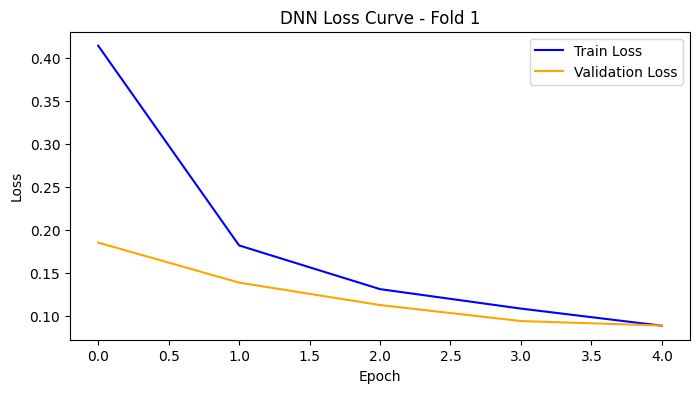

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[*] New best DNN saved! (Accuracy: 0.9740)

--- Training CNN (Fold 1) ---
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.8470 - loss: 0.5076 - val_accuracy: 0.9560 - val_loss: 0.1491
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9562 - loss: 0.1438 - val_accuracy: 0.9731 - val_loss: 0.0907
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9686 - loss: 0.1022 - val_accuracy: 0.9764 - val_loss: 0.0764
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9752 - loss: 0.0831 - val_accuracy: 0.9804 - val_loss: 0.0609
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9778 - loss: 0.0697 - val_accuracy: 0.9827 - val_loss: 0.0548


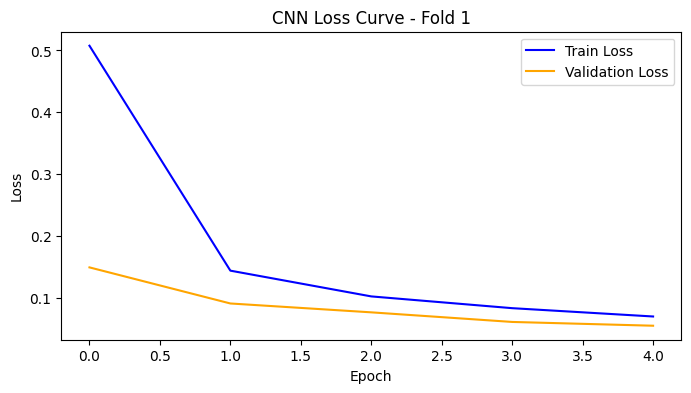

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


[*] New best CNN saved! (Accuracy: 0.9841)

Starting Fold 2 / 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Training DNN (Fold 2) ---
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8752 - loss: 0.4235 - val_accuracy: 0.9472 - val_loss: 0.1836
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9461 - loss: 0.1805 - val_accuracy: 0.9565 - val_loss: 0.1423
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9587 - loss: 0.1357 - val_accuracy: 0.9650 - val_loss: 0.1161
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9665 - loss: 0.1102 - val_accuracy: 0.9670 - val_loss: 0.1051
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9715 - loss: 0.0920 - val_accuracy: 0.9726 - val_loss: 0.0962


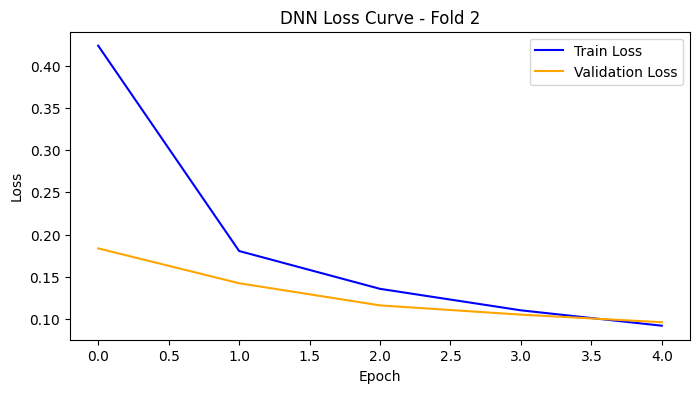

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


[*] New best DNN saved! (Accuracy: 0.9749)

--- Training CNN (Fold 2) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8619 - loss: 0.4792 - val_accuracy: 0.9627 - val_loss: 0.1267
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9622 - loss: 0.1237 - val_accuracy: 0.9747 - val_loss: 0.0865
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9729 - loss: 0.0883 - val_accuracy: 0.9798 - val_loss: 0.0662
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9787 - loss: 0.0698 - val_accuracy: 0.9837 - val_loss: 0.0549
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9807 - loss: 0.0612 - val_accuracy: 0.9850 - val_loss: 0.0510


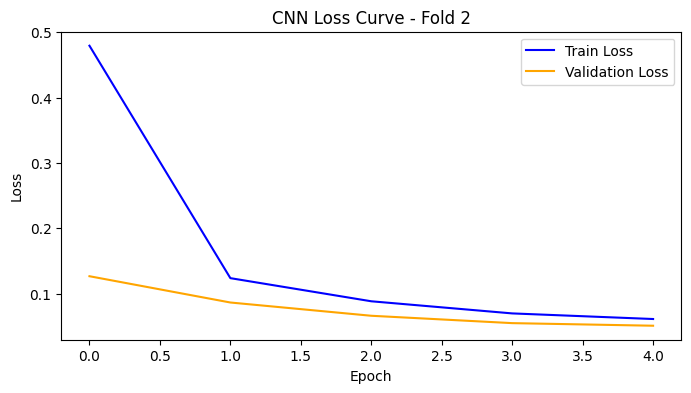

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


[*] New best CNN saved! (Accuracy: 0.9862)

Starting Fold 3 / 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Training DNN (Fold 3) ---
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8755 - loss: 0.4255 - val_accuracy: 0.9437 - val_loss: 0.1851
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9459 - loss: 0.1811 - val_accuracy: 0.9607 - val_loss: 0.1328
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9603 - loss: 0.1332 - val_accuracy: 0.9656 - val_loss: 0.1146
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9672 - loss: 0.1099 - val_accuracy: 0.9682 - val_loss: 0.1028
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9709 - loss: 0.0934 - val_accuracy: 0.9715 - val_loss: 0.0944


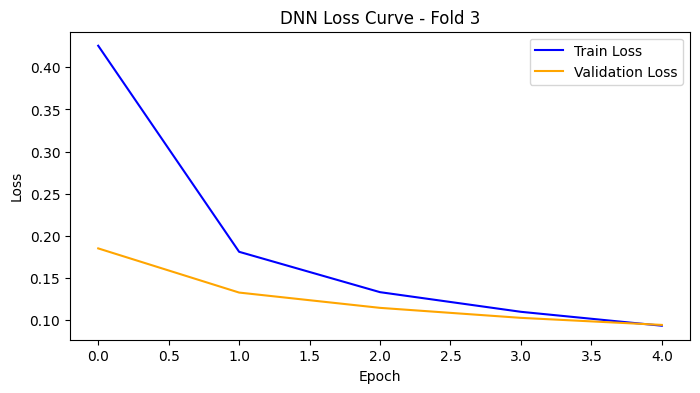

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Training CNN (Fold 3) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.8705 - loss: 0.4322 - val_accuracy: 0.9596 - val_loss: 0.1324
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9574 - loss: 0.1409 - val_accuracy: 0.9674 - val_loss: 0.1009
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9681 - loss: 0.1039 - val_accuracy: 0.9763 - val_loss: 0.0768
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9742 - loss: 0.0851 - val_accuracy: 0.9784 - val_loss: 0.0707
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9759 - loss: 0.0746 - val_accuracy: 0.9767 - val_loss: 0.0699


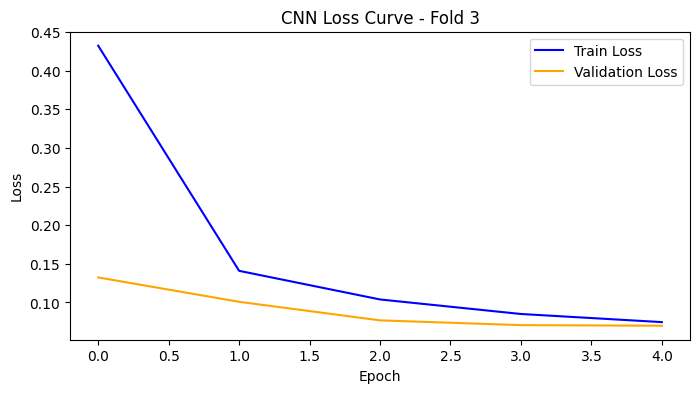

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Starting Fold 4 / 6

--- Training DNN (Fold 4) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8794 - loss: 0.4113 - val_accuracy: 0.9478 - val_loss: 0.1766
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9456 - loss: 0.1822 - val_accuracy: 0.9617 - val_loss: 0.1251
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9594 - loss: 0.1358 - val_accuracy: 0.9644 - val_loss: 0.1106
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9673 - loss: 0.1085 - val_accuracy: 0.9718 - val_loss: 0.0885
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9708 - loss: 0.0933 - val_accuracy: 0.9735 - val_loss: 0.0826


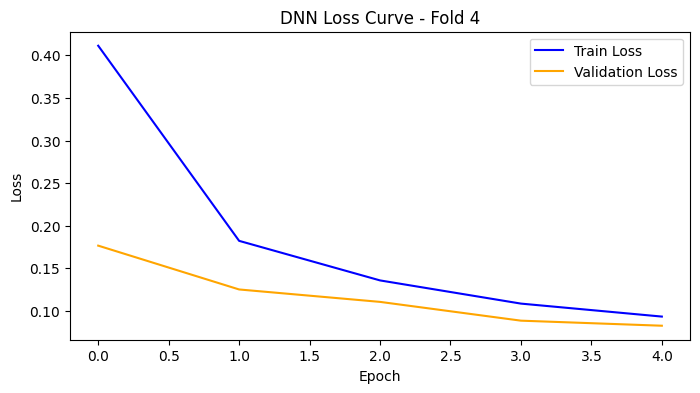

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Training CNN (Fold 4) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.8636 - loss: 0.4507 - val_accuracy: 0.9560 - val_loss: 0.1414
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9559 - loss: 0.1438 - val_accuracy: 0.9682 - val_loss: 0.0972
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9681 - loss: 0.1039 - val_accuracy: 0.9769 - val_loss: 0.0730
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.9737 - loss: 0.0870 - val_accuracy: 0.9810 - val_loss: 0.0592
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9771 - loss: 0.0766 - val_accuracy: 0.9819 - val_loss: 0.0565


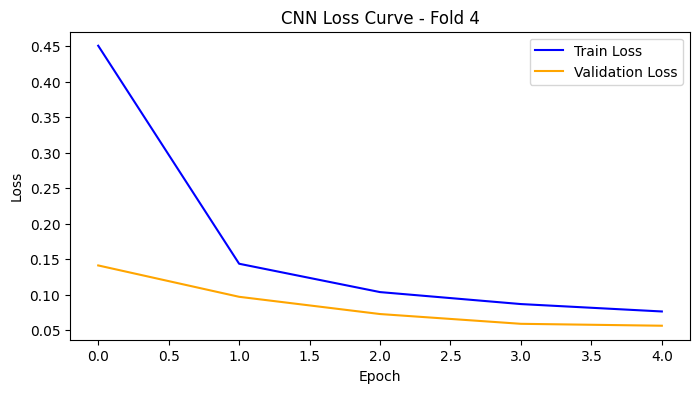

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Starting Fold 5 / 6

--- Training DNN (Fold 5) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8787 - loss: 0.4132 - val_accuracy: 0.9392 - val_loss: 0.2066
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9476 - loss: 0.1749 - val_accuracy: 0.9569 - val_loss: 0.1493
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9604 - loss: 0.1306 - val_accuracy: 0.9670 - val_loss: 0.1164
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9679 - loss: 0.1054 - val_accuracy: 0.9683 - val_loss: 0.1066
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9727 - loss: 0.0890 - val_accuracy: 0.9703 - val_loss: 0.0994


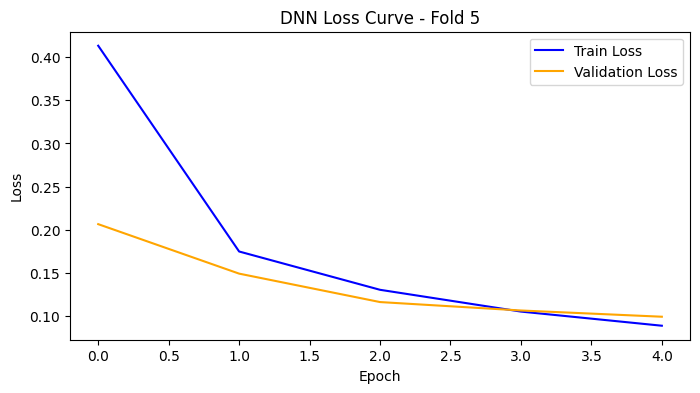

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Training CNN (Fold 5) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8719 - loss: 0.4293 - val_accuracy: 0.9586 - val_loss: 0.1385
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9619 - loss: 0.1258 - val_accuracy: 0.9686 - val_loss: 0.1026
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.9717 - loss: 0.0912 - val_accuracy: 0.9771 - val_loss: 0.0774
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9766 - loss: 0.0757 - val_accuracy: 0.9780 - val_loss: 0.0684
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9803 - loss: 0.0648 - val_accuracy: 0.9776 - val_loss: 0.0721


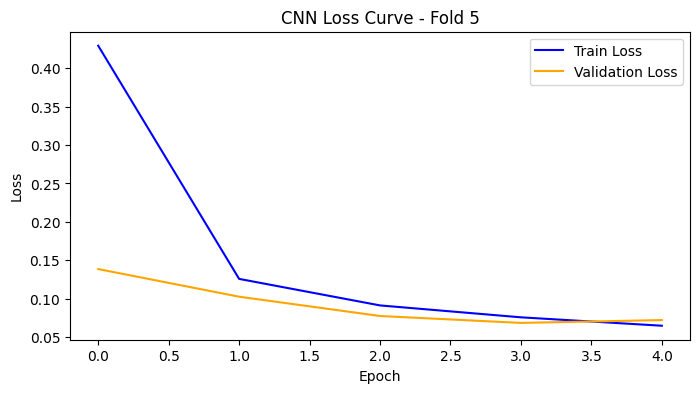

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Starting Fold 6 / 6

--- Training DNN (Fold 6) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8785 - loss: 0.4213 - val_accuracy: 0.9429 - val_loss: 0.1901
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9457 - loss: 0.1838 - val_accuracy: 0.9572 - val_loss: 0.1400
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9595 - loss: 0.1371 - val_accuracy: 0.9655 - val_loss: 0.1142
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9665 - loss: 0.1085 - val_accuracy: 0.9670 - val_loss: 0.1023
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9716 - loss: 0.0939 - val_accuracy: 0.9697 - val_loss: 0.0940


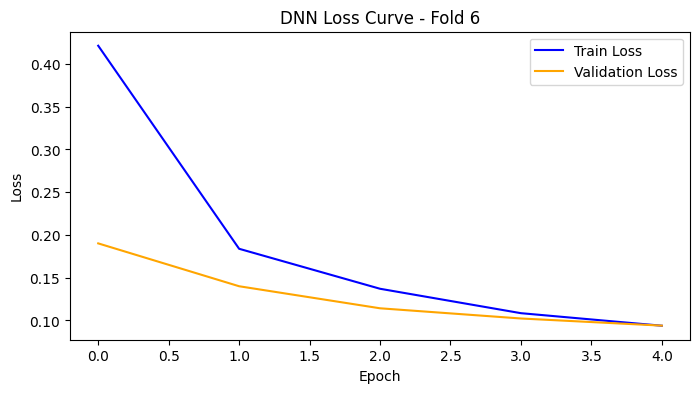

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Training CNN (Fold 6) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8587 - loss: 0.4737 - val_accuracy: 0.9511 - val_loss: 0.1629
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9549 - loss: 0.1500 - val_accuracy: 0.9669 - val_loss: 0.1062
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9673 - loss: 0.1075 - val_accuracy: 0.9766 - val_loss: 0.0805
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9739 - loss: 0.0869 - val_accuracy: 0.9778 - val_loss: 0.0735
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9779 - loss: 0.0728 - val_accuracy: 0.9800 - val_loss: 0.0662


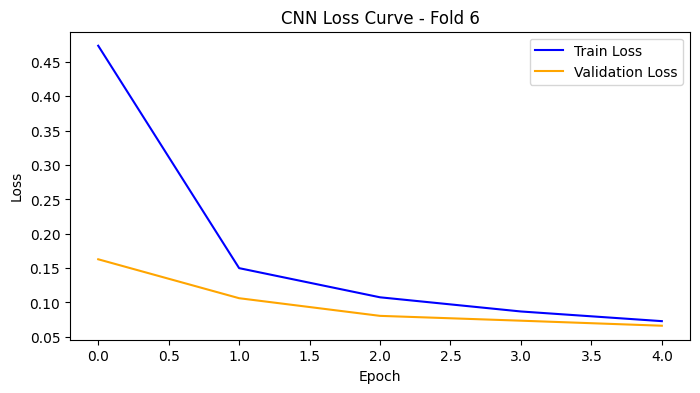

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

All folds completed successfully!
Results saved to 'erotima1.csv' and best models saved as .h5 files.


,Technique name,Set,Fold number,Accuracy,Precision,Recall,F1 score
0,DNN,Train,1,0.98438,0.984441,0.984326,0.984343
1,DNN,Test,1,0.97400,0.973971,0.973884,0.973870
2,CNN,Train,1,0.98676,0.986686,0.986698,0.986683
3,CNN,Test,1,0.98410,0.984041,0.983967,0.983983
4,DNN,Train,2,0.98414,0.984065,0.984133,0.984061
5,DNN,Test,2,0.97490,0.974863,0.974755,0.974726
6,CNN,Train,2,0.98880,0.988733,0.988797,0.988755
7,CNN,Test,2,0.98620,0.986082,0.986136,0.986082
8,DNN,Train,3,0.98416,0.984164,0.984035,0.984060
9,DNN,Test,3,0.97410,0.974120,0.973899,0.973938


In [5]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize an empty list to store the results of each experiment
results_list =[]

# Variables to keep track of the highest Test Accuracy for both models
best_dnn_acc = 0
best_cnn_acc = 0

# The Test Set labels are currently One-Hot encoded [0,0,0,1,...]
# We need them as simple digits [3] to calculate the metrics easily
y_test_true = np.argmax(y_test, axis=1)

# Set the number of epochs (how many times the network reads the data per fold)
# We set it to 5 for speed. You can increase it to 10 or 20 later if you want.
EPOCHS = 5

# 2. Start the K-Fold Loop
# skf.split will divide the 60,000 images into 50k for training and 10k for validation
for fold_index, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train_original)):
    fold_num = fold_index + 1
    print(f"\n{'='*40}")
    print(f"Starting Fold {fold_num} / 6")
    print(f"{'='*40}")

    # 2a. Create the independent Train and Validation sets for this specific fold
    x_fold_train = x_train[train_idx]
    y_fold_train = y_train[train_idx]

    x_fold_val = x_train[val_idx]
    y_fold_val = y_train[val_idx]

    # Convert one-hot labels back to normal digits for the Train metrics later
    y_fold_train_true = np.argmax(y_fold_train, axis=1)

    # We will run the exact same process for both DNN and CNN
    for technique in['DNN', 'CNN']:
        print(f"\n--- Training {technique} (Fold {fold_num}) ---")

        # 3. Create a fresh model
        if technique == 'DNN':
            model = create_dnn_model()
        else:
            model = create_cnn_model()

        # 4. Train the model using the Validation set
        # Rule 3b: validation data must be independent.
        history = model.fit(x_fold_train, y_fold_train,
                            validation_data=(x_fold_val, y_fold_val),
                            epochs=EPOCHS,
                            batch_size=128,
                            verbose=1) # verbose=1 prints the loss on the screen

        # 5. Plot the Training and Validation Loss Curves
        # Rule 3c: Plot training history
        plt.figure(figsize=(8, 4))
        plt.plot(history.history['loss'], label='Train Loss', color='blue')
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
        plt.title(f'{technique} Loss Curve - Fold {fold_num}')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()
        plt.show()

        # 6. Predict on Train and Test Sets
        # Predict on the current Train set
        train_predictions = model.predict(x_fold_train)
        train_pred_classes = np.argmax(train_predictions, axis=1)

        # Predict on the official Test set (always the 10,000 samples)
        test_predictions = model.predict(x_test)
        test_pred_classes = np.argmax(test_predictions, axis=1)

        # 7. Calculate Metrics (Accuracy, Precision, Recall, F1)
        # We use zero_division=0 to prevent warnings if the network guesses completely wrong initially
        tr_acc = accuracy_score(y_fold_train_true, train_pred_classes)
        tr_prec = precision_score(y_fold_train_true, train_pred_classes, average='macro', zero_division=0)
        tr_rec = recall_score(y_fold_train_true, train_pred_classes, average='macro', zero_division=0)
        tr_f1 = f1_score(y_fold_train_true, train_pred_classes, average='macro', zero_division=0)

        te_acc = accuracy_score(y_test_true, test_pred_classes)
        te_prec = precision_score(y_test_true, test_pred_classes, average='macro', zero_division=0)
        te_rec = recall_score(y_test_true, test_pred_classes, average='macro', zero_division=0)
        te_f1 = f1_score(y_test_true, test_pred_classes, average='macro', zero_division=0)

        # 8. Save the results as a row in our list
        # Format: Technique name | Set | Fold number | Accuracy | Precision | Recall | F1 score
        results_list.append([f"{technique}", "Train", fold_num, tr_acc, tr_prec, tr_rec, tr_f1])
        results_list.append([f"{technique}", "Test", fold_num, te_acc, te_prec, te_rec, te_f1])

        # 9. Save the best model (.h5) based on Test Accuracy
        # Rule 4: save the DNN and CNN with the best results on the test set across the 6 folds.
        if technique == 'DNN' and te_acc > best_dnn_acc:
            best_dnn_acc = te_acc
            model.save('best_dnn_model.h5')
            print(f"[*] New best DNN saved! (Accuracy: {te_acc:.4f})")

        elif technique == 'CNN' and te_acc > best_cnn_acc:
            best_cnn_acc = te_acc
            model.save('best_cnn_model.h5')
            print(f"[*] New best CNN saved! (Accuracy: {te_acc:.4f})")

# 10. Convert the list of results into a Pandas DataFrame
columns_names =['Technique name', 'Set', 'Fold number', 'Accuracy', 'Precision', 'Recall', 'F1 score']
df_results = pd.DataFrame(results_list, columns=columns_names)

# Save the DataFrame to a CSV file (Rule 3e)
df_results.to_csv('erotima1.csv', index=False)

print("\nAll folds completed successfully!")
print("Results saved to 'erotima1.csv' and best models saved as .h5 files.")

# Display the final DataFrame
display(df_results)

* Plot drawing

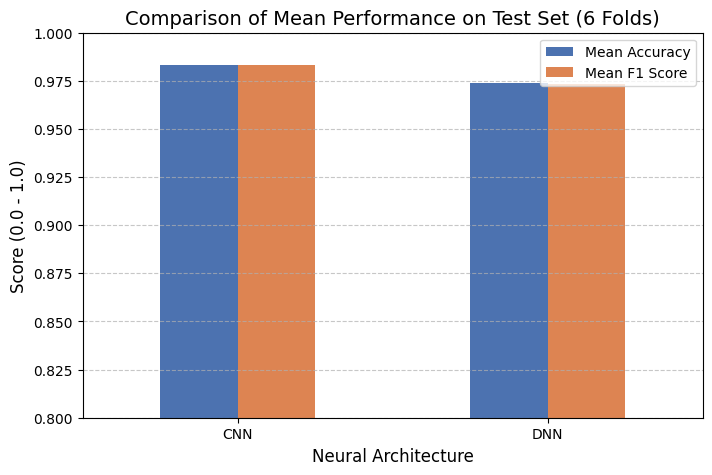

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the results file
df = pd.read_csv('erotima1.csv')

# Keep ONLY the Test Set results (these show the true performance)
test_df = df[df['Set'] == 'Test']

# Calculate the mean Accuracy and F1 score for each technique (DNN / CNN)
summary_df = test_df.groupby('Technique name')[['Accuracy', 'F1 score']].mean().reset_index()

# Create the chart (Bar Chart)
fig, ax = plt.subplots(figsize=(8, 5))
summary_df.plot(x='Technique name', y=['Accuracy', 'F1 score'], kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])

# Beautify the chart
plt.title('Comparison of Mean Performance on Test Set (6 Folds)', fontsize=14)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Neural Architecture', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Mean Accuracy', 'Mean F1 Score'])
plt.ylim(0.8, 1.0) # Start Y-axis from 0.8 for better visibility of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the chart
plt.show()